# Phase 2: BiLSTM + GloVe Embeddings

**What we're doing:** Building a Bidirectional LSTM that reads comments word-by-word and classifies toxicity. Unlike TF-IDF (which treats text as a bag of words), the BiLSTM understands **word order** and **context**.

**What we're using:**
- **GloVe embeddings**: Pre-trained word vectors (each word = 100 numbers that capture meaning)
- **BiLSTM**: Reads text forward AND backward, maintaining memory of what it's read
- **Focal Loss**: Pays extra attention to hard/rare examples (handles class imbalance)
- **MPS (Metal)**: Apple M3 GPU acceleration

**Goal:** Beat the TF-IDF baseline (Macro F1: 0.5633, Macro AUC: 0.9810)

In [1]:
# Setup: path so we can import from src/
import sys
sys.path.insert(0, '..')

# Standard libraries
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json
import time

# PyTorch
import torch
from torch.utils.data import DataLoader

# Our modules
from src.dataset import (
    load_data, get_splits, LABEL_COLS,
    Vocabulary, ToxicDataset
)
from src.models import BiLSTMClassifier, load_glove_embeddings
from src.training import get_device, FocalLoss, train_model, evaluate
from src.metrics import evaluate_predictions, print_metrics, save_results, load_all_results, print_comparison_table

# Plot settings
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

print(f'PyTorch version: {torch.__version__}')
device = get_device()
print('All imports successful!')

PyTorch version: 2.11.0
Using MPS (Apple M3 GPU)
All imports successful!


---
## Part 1: Load Data and Build Vocabulary

Same data splits as Phase 1 (same `random_state=42`), so the train/val/test sets are identical. Fair comparison.

In [2]:
# Load and split — same as Phase 1
df = load_data(data_dir='../data')
train_df, val_df, test_df = get_splits(df)
print(f'Train: {len(train_df):,}  Val: {len(val_df):,}  Test: {len(test_df):,}')

Train: 127,656  Val: 15,957  Test: 15,958


In [3]:
# Build vocabulary from training data ONLY
# max_size=50000: keep the 50K most common words
# This creates our word → index mapping
vocab = Vocabulary(max_size=50000).build(train_df['comment_text'])

# Let's look at some mappings
sample_words = ['the', 'idiot', 'stupid', 'hello', 'threat', 'kill']
print('\nSample word → index mappings:')
for word in sample_words:
    idx = vocab.word_to_idx.get(word, 'NOT FOUND')
    print(f'  "{word}" → {idx}')

Vocabulary built: 50,000 words (from 403,821 unique words in training data)

Sample word → index mappings:
  "the" → 2
  "idiot" → 1981
  "stupid" → 582
  "hello" → 653
  "threat" → 2601
  "kill" → 842


---
## Part 2: Load GloVe Embeddings

GloVe gives us pre-trained word vectors. Each word is represented by 100 numbers that capture its meaning. Words with similar meanings have similar vectors.

We load the GloVe file and match it to our vocabulary. Words in our vocabulary that GloVe doesn't have get random vectors.

In [4]:
# Load GloVe vectors aligned to our vocabulary
# This reads the 331MB file and extracts vectors for words we need
glove_embeddings = load_glove_embeddings(
    glove_path='../data/glove.6B.100d.txt',
    word_to_idx=vocab.word_to_idx,
    embedding_dim=100,
)

print(f'Embedding matrix shape: {glove_embeddings.shape}')
print(f'  → {glove_embeddings.shape[0]:,} words, each as a {glove_embeddings.shape[1]}-dim vector')

GloVe: found vectors for 26,022/50,000 words (52.0% coverage)
Embedding matrix shape: (50000, 100)
  → 50,000 words, each as a 100-dim vector


In [5]:
# Let's verify GloVe captures word similarity
# Cosine similarity: 1.0 = identical meaning, 0.0 = unrelated
from numpy.linalg import norm

def cosine_sim(word1, word2):
    idx1 = vocab.word_to_idx.get(word1)
    idx2 = vocab.word_to_idx.get(word2)
    if idx1 is None or idx2 is None:
        return None
    v1 = glove_embeddings[idx1]
    v2 = glove_embeddings[idx2]
    return np.dot(v1, v2) / (norm(v1) * norm(v2))

pairs = [
    ('idiot', 'stupid'),     # similar meaning → high similarity
    ('idiot', 'moron'),      # similar meaning → high similarity
    ('king', 'queen'),       # related → moderate similarity
    ('idiot', 'sunshine'),   # unrelated → low similarity
    ('good', 'bad'),         # opposite meaning but same context → moderate
    ('kill', 'murder'),      # similar → high
]

print('GloVe word similarity (cosine):')  
for w1, w2 in pairs:
    sim = cosine_sim(w1, w2)
    if sim is not None:
        bar = '█' * int(sim * 20)
        print(f'  {w1:>10s} ↔ {w2:<10s}: {sim:.3f}  {bar}')

GloVe word similarity (cosine):
       idiot ↔ stupid    : 0.516  ██████████
       idiot ↔ moron     : 0.499  █████████
        king ↔ queen     : 0.751  ███████████████
       idiot ↔ sunshine  : 0.079  █
        good ↔ bad       : 0.770  ███████████████
        kill ↔ murder    : 0.562  ███████████


---
## Part 3: Create PyTorch Datasets and DataLoaders

**Dataset**: Holds all comments. When you ask for `dataset[42]`, it returns comment #42 as encoded word indices + its labels.

**DataLoader**: Wraps a Dataset and serves **batches** (groups of 32). The GPU processes all 32 comments in parallel at each time step.

**max_length=200**: All comments are padded/truncated to 200 words. This ensures all comments in a batch are the same length (required for GPU matrix operations).

In [6]:
MAX_LENGTH = 200  # pad/truncate all comments to this length
BATCH_SIZE = 32   # process 32 comments at a time

# Create datasets
train_dataset = ToxicDataset(train_df, vocab, max_length=MAX_LENGTH)
val_dataset = ToxicDataset(val_df, vocab, max_length=MAX_LENGTH)

# Create data loaders
# shuffle=True for training (see data in different order each epoch)
# shuffle=False for validation (consistent evaluation)
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)

print(f'Training: {len(train_dataset):,} samples → {len(train_loader):,} batches of {BATCH_SIZE}')
print(f'Validation: {len(val_dataset):,} samples → {len(val_loader):,} batches of {BATCH_SIZE}')

# Peek at one batch
batch = next(iter(train_loader))
print(f'\nBatch shapes:')
print(f'  input_ids: {batch["input_ids"].shape}  (32 comments, 200 words each)')
print(f'  labels:    {batch["labels"].shape}  (32 comments, 6 labels each)')

Training: 127,656 samples → 3,990 batches of 32
Validation: 15,957 samples → 499 batches of 32

Batch shapes:
  input_ids: torch.Size([32, 200])  (32 comments, 200 words each)
  labels:    torch.Size([32, 6])  (32 comments, 6 labels each)


---
## Part 4: Create the BiLSTM Model

Our architecture:
```
word indices → GloVe embedding (frozen) → BiLSTM (2 layers) → dropout → linear → 6 scores
```

Key settings:
- `embedding_dim=100`: GloVe vectors are 100-dimensional
- `hidden_dim=128`: each LSTM direction produces 128-dim output
- `num_layers=2`: two stacked LSTM layers (deeper understanding)
- `dropout=0.3`: randomly zero out 30% during training (prevents overfitting)
- `pretrained_embeddings`: load our GloVe vectors (frozen, not updated)

In [7]:
model = BiLSTMClassifier(
    vocab_size=len(vocab),
    embedding_dim=100,
    hidden_dim=128,
    num_labels=6,
    num_layers=2,
    dropout=0.3,
    pretrained_embeddings=glove_embeddings,
)

# Move model to GPU (MPS)
model = model.to(device)

# Count parameters
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
frozen_params = total_params - trainable_params

print(f'Model created and moved to {device}')
print(f'  Total parameters:     {total_params:>10,}')
print(f'  Trainable parameters: {trainable_params:>10,}  (LSTM + linear)')
print(f'  Frozen parameters:    {frozen_params:>10,}  (GloVe embeddings)')

Model created and moved to mps
  Total parameters:      5,632,326
  Trainable parameters:    632,326  (LSTM + linear)
  Frozen parameters:     5,000,000  (GloVe embeddings)


---
## Part 5: Setup Training

Three things to configure:
1. **Loss function**: Focal Loss (γ=2) — focuses on hard/rare examples
2. **Optimizer**: Adam — adaptive learning rate per parameter
3. **Training settings**: 10 epochs max, early stopping with patience=3

In [8]:
# Focal Loss: gamma=2 means strong focus on hard examples
# (examples the model gets wrong contribute MORE to the loss)
loss_fn = FocalLoss(alpha=1.0, gamma=2.0)

# Adam optimizer: only update trainable parameters (not frozen GloVe)
# lr=0.001 is the default learning rate for Adam — a good starting point
# filter(lambda p: p.requires_grad, ...) skips the frozen embedding weights
optimizer = torch.optim.Adam(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=0.001,
)

print(f'Loss function: Focal Loss (gamma=2.0)')
print(f'Optimizer: Adam (lr=0.001)')
print(f'Max epochs: 10, Early stopping patience: 3')

Loss function: Focal Loss (gamma=2.0)
Optimizer: Adam (lr=0.001)
Max epochs: 10, Early stopping patience: 3


---
## Part 6: Train!

This is where the model actually learns. Watch the train and val loss decrease epoch by epoch.

**What to look for:**
- Train loss should decrease steadily
- Val loss should decrease too (model is learning, not just memorizing)
- If val loss starts INCREASING while train loss decreases → overfitting → early stopping kicks in

Expected time: ~2-4 minutes per epoch on M3.

In [9]:
# Train the model!
history = train_model(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    loss_fn=loss_fn,
    optimizer=optimizer,
    device=device,
    n_epochs=10,
    patience=3,
    save_path='../models/bilstm_glove.pt',
)

Training for up to 10 epochs (patience=3)...
 Epoch | Train Loss |   Val Loss |   Time |          Status
------------------------------------------------------------


     1 |     0.0215 |     0.0180 | 184.8s |    * new best *


     2 |     0.0177 |     0.0170 | 180.1s |    * new best *


     3 |     0.0163 |     0.0161 | 178.7s |    * new best *


     4 |     0.0152 |     0.0163 | 171.5s | no improve (1/3)


     5 |     0.0143 |     0.0161 | 171.2s | no improve (2/3)


     6 |     0.0135 |     0.0159 | 177.4s |    * new best *


     7 |     0.0127 |     0.0161 | 394.6s | no improve (1/3)


     8 |     0.0118 |     0.0173 | 172.2s | no improve (2/3)


     9 |     0.0111 |     0.0172 | 173.2s | no improve (3/3)

Early stopping: no improvement for 3 epochs.
Restored best model (val_loss: 0.0159)


---
## Part 7: Training Curves

Plot train loss vs val loss over epochs. This tells us:
- Is the model learning? (both curves going down)
- Is it overfitting? (train goes down, val goes up)
- Did early stopping trigger at the right time?

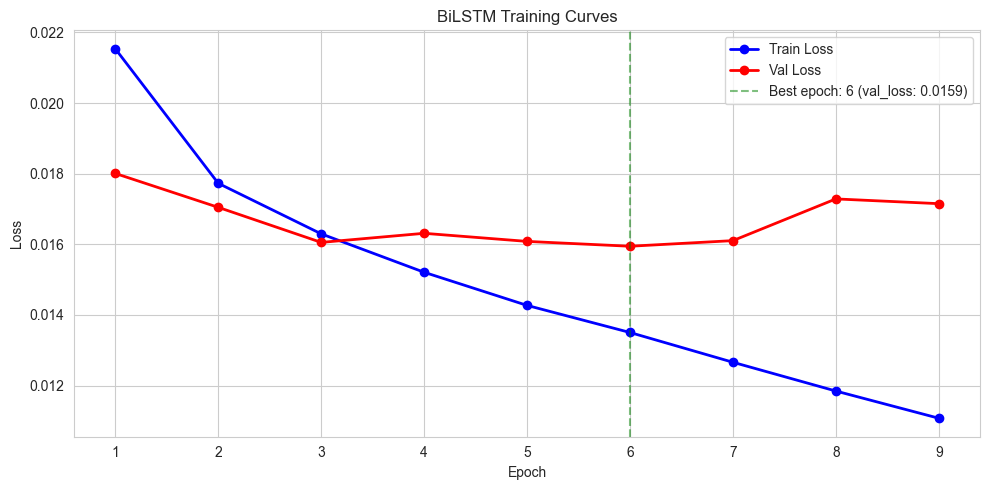

In [10]:
fig, ax = plt.subplots(figsize=(10, 5))

epochs = range(1, len(history['train_loss']) + 1)
ax.plot(epochs, history['train_loss'], 'b-o', label='Train Loss', linewidth=2)
ax.plot(epochs, history['val_loss'], 'r-o', label='Val Loss', linewidth=2)

# Mark the best epoch
best_epoch = np.argmin(history['val_loss']) + 1
best_val_loss = min(history['val_loss'])
ax.axvline(x=best_epoch, color='green', linestyle='--', alpha=0.5,
           label=f'Best epoch: {best_epoch} (val_loss: {best_val_loss:.4f})')

ax.set_xlabel('Epoch')
ax.set_ylabel('Loss')
ax.set_title('BiLSTM Training Curves')
ax.legend()

plt.tight_layout()
plt.savefig('../results/bilstm_training_curves.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Part 8: Evaluate on Validation Set

Now let's see the actual F1 and ROC-AUC numbers and compare with the TF-IDF baseline.

In [11]:
# Evaluate on validation set
val_results = evaluate(model, val_loader, loss_fn, device)

# Compute metrics
bilstm_results = evaluate_predictions(
    y_true=val_results['labels'],
    y_pred=val_results['predictions'],
    y_proba=val_results['probabilities'],
)

# Print
print_metrics(bilstm_results, 'BiLSTM + GloVe')


  BiLSTM + GloVe — Evaluation Results
          Label |     F1 |   Prec |    Rec |    AUC | Support
----------------------------------------------------------------------
          toxic | 0.7367 | 0.8400 | 0.6560 | 0.9581 |    1529
   severe_toxic | 0.2524 | 0.5652 | 0.1625 | 0.9854 |     160
        obscene | 0.7377 | 0.8111 | 0.6765 | 0.9713 |     844
         threat | 0.4000 | 0.4595 | 0.3542 | 0.9686 |      48
         insult | 0.6531 | 0.7297 | 0.5911 | 0.9677 |     790
  identity_hate | 0.2703 | 0.5682 | 0.1773 | 0.9737 |     141
----------------------------------------------------------------------
      MACRO AVG | 0.5084 | 0.6623 | 0.4363 | 0.9708 |



In [12]:
# Save results
save_results(bilstm_results, 'bilstm_glove', results_dir='../results')

Results saved to ../results/bilstm_glove_results.json


---
## Part 9: Compare with Baseline

The whole point: did the BiLSTM beat TF-IDF + Logistic Regression?

In [13]:
# Load all saved results and compare
all_results = load_all_results(results_dir='../results')
print_comparison_table(all_results)


  MODEL COMPARISON
Model                     | Macro F1 | Macro AUC |       threat F1 | identity_hate F1
--------------------------------------------------------------------------------
bilstm_glove              |   0.5084 |    0.9708 |          0.4000 |          0.2703
tfidf_logreg              |   0.5633 |    0.9810 |          0.4048 |          0.3783



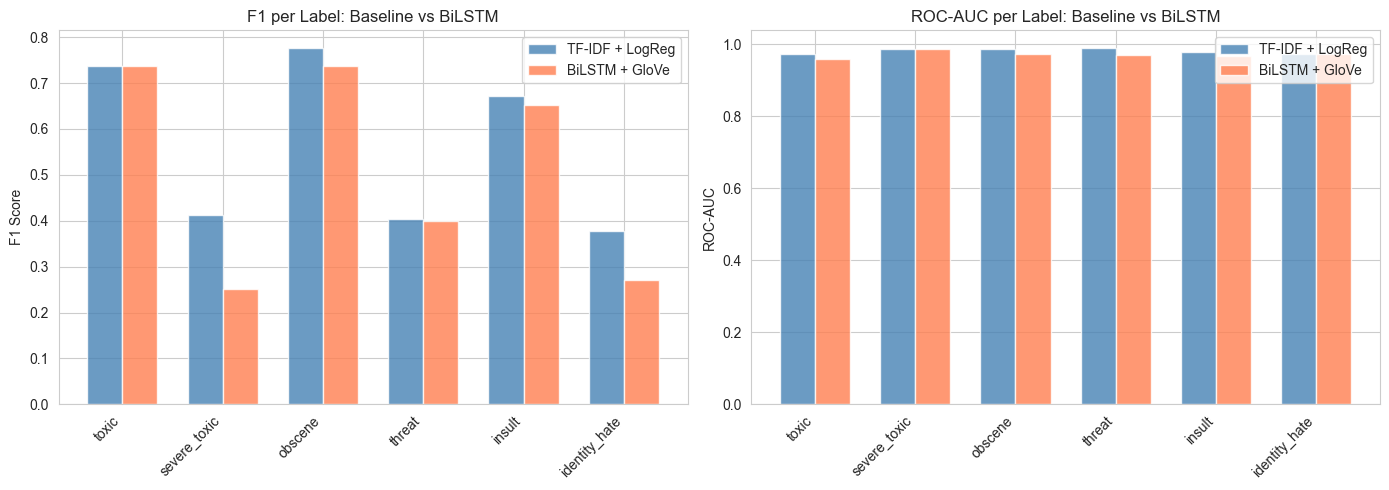


Macro F1 improvement: 0.5633 → 0.5084 (-0.0549)
Macro AUC improvement: 0.9810 → 0.9708 (-0.0102)


In [14]:
# Visual comparison: F1 per label
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Load baseline results
with open('../results/tfidf_logreg_results.json') as f:
    baseline = json.load(f)

labels = LABEL_COLS
x = np.arange(len(labels))
width = 0.35

# F1 comparison
baseline_f1 = [baseline['per_label'][l]['f1'] for l in labels]
bilstm_f1 = [bilstm_results['per_label'][l]['f1'] for l in labels]

axes[0].bar(x - width/2, baseline_f1, width, label='TF-IDF + LogReg', color='steelblue', alpha=0.8)
axes[0].bar(x + width/2, bilstm_f1, width, label='BiLSTM + GloVe', color='coral', alpha=0.8)
axes[0].set_xticks(x)
axes[0].set_xticklabels(labels, rotation=45, ha='right')
axes[0].set_ylabel('F1 Score')
axes[0].set_title('F1 per Label: Baseline vs BiLSTM')
axes[0].legend()

# ROC-AUC comparison
baseline_auc = [baseline['per_label'][l]['roc_auc'] for l in labels]
bilstm_auc = [bilstm_results['per_label'][l]['roc_auc'] for l in labels]

axes[1].bar(x - width/2, baseline_auc, width, label='TF-IDF + LogReg', color='steelblue', alpha=0.8)
axes[1].bar(x + width/2, bilstm_auc, width, label='BiLSTM + GloVe', color='coral', alpha=0.8)
axes[1].set_xticks(x)
axes[1].set_xticklabels(labels, rotation=45, ha='right')
axes[1].set_ylabel('ROC-AUC')
axes[1].set_title('ROC-AUC per Label: Baseline vs BiLSTM')
axes[1].legend()

plt.tight_layout()
plt.savefig('../results/bilstm_vs_baseline.png', dpi=150, bbox_inches='tight')
plt.show()

# Print improvement
print(f'\nMacro F1 improvement: {baseline["macro"]["f1"]:.4f} → {bilstm_results["macro"]["f1"]:.4f} '
      f'({bilstm_results["macro"]["f1"] - baseline["macro"]["f1"]:+.4f})')
print(f'Macro AUC improvement: {baseline["macro"]["roc_auc"]:.4f} → {bilstm_results["macro"]["roc_auc"]:.4f} '
      f'({bilstm_results["macro"]["roc_auc"] - baseline["macro"]["roc_auc"]:+.4f})')

---
## Part 10: Error Analysis

Let's look at specific examples where the BiLSTM and baseline disagree. This helps us understand **what** the BiLSTM learned that TF-IDF couldn't.

In [15]:
# Predict on some example comments to see the model in action
examples = [
    "You are a complete idiot and should be banned",
    "Thank you for your contributions to this article",
    "This is not a bad edit at all, well done",
    "I will find you and destroy everything you care about",
    "Please stop removing content from pages",
]

model.eval()
print('BiLSTM predictions on example comments:')
print('=' * 70)

for text in examples:
    # Encode the text
    indices = vocab.encode(text, max_length=MAX_LENGTH)
    input_tensor = torch.tensor([indices], dtype=torch.long).to(device)
    
    # Predict
    with torch.no_grad():
        logits = model(input_tensor)
        probs = torch.sigmoid(logits).cpu().numpy()[0]
    
    print(f'\n"{text}"')
    for label, prob in zip(LABEL_COLS, probs):
        bar = '█' * int(prob * 30)
        flag = ' ← FLAGGED' if prob > 0.5 else ''
        print(f'  {label:>15s}: {prob:.3f} {bar}{flag}')

BiLSTM predictions on example comments:



"You are a complete idiot and should be banned"
            toxic: 0.656 ███████████████████ ← FLAGGED
     severe_toxic: 0.127 ███
          obscene: 0.391 ███████████
           threat: 0.052 █
           insult: 0.523 ███████████████ ← FLAGGED
    identity_hate: 0.156 ████

"Thank you for your contributions to this article"
            toxic: 0.074 ██
     severe_toxic: 0.006 
          obscene: 0.075 ██
           threat: 0.011 
           insult: 0.047 █
    identity_hate: 0.017 

"This is not a bad edit at all, well done"
            toxic: 0.171 █████
     severe_toxic: 0.014 
          obscene: 0.128 ███
           threat: 0.040 █
           insult: 0.101 ███
    identity_hate: 0.053 █

"I will find you and destroy everything you care about"
            toxic: 0.415 ████████████
     severe_toxic: 0.080 ██
          obscene: 0.189 █████
           threat: 0.228 ██████
           insult: 0.199 █████
    identity_hate: 0.103 ███

"Please stop removing content from pages"
       

---
## Part 11: Overfitting Check

Same check as Phase 1: compare train F1 vs val F1. With dropout + early stopping, we expect less overfitting than the baseline.

In [16]:
# Evaluate on training set too (for overfitting check)
train_eval = evaluate(model, train_loader, loss_fn, device)
train_metrics = evaluate_predictions(
    y_true=train_eval['labels'],
    y_pred=train_eval['predictions'],
    y_proba=train_eval['probabilities'],
)

print('Overfitting check: Train F1 vs Val F1')
print(f'{"Label":<15} {"Train F1":>8} {"Val F1":>8} {"Gap":>8}')
print('-' * 42)
for label in LABEL_COLS:
    t_f1 = train_metrics['per_label'][label]['f1']
    v_f1 = bilstm_results['per_label'][label]['f1']
    gap = t_f1 - v_f1
    flag = ' ← overfit' if gap > 0.10 else ''
    print(f'{label:<15} {t_f1:>8.4f} {v_f1:>8.4f} {gap:>+8.4f}{flag}')

t_macro = train_metrics['macro']['f1']
v_macro = bilstm_results['macro']['f1']
print('-' * 42)
print(f'{"MACRO":<15} {t_macro:>8.4f} {v_macro:>8.4f} {t_macro-v_macro:>+8.4f}')

Overfitting check: Train F1 vs Val F1
Label           Train F1   Val F1      Gap
------------------------------------------
toxic             0.7843   0.7367  +0.0476
severe_toxic      0.3532   0.2524  +0.1008 ← overfit
obscene           0.7873   0.7377  +0.0496
threat            0.4794   0.4000  +0.0794
insult            0.7305   0.6531  +0.0774
identity_hate     0.4016   0.2703  +0.1313 ← overfit
------------------------------------------
MACRO             0.5894   0.5084  +0.0810


---
## Summary

Phase 2 results will appear above after training completes.

In [17]:
print('=' * 50)
print('  PHASE 2 SUMMARY: BiLSTM + GloVe')
print('=' * 50)
print(f'  Macro F1:  {bilstm_results["macro"]["f1"]:.4f}')
print(f'  Macro AUC: {bilstm_results["macro"]["roc_auc"]:.4f}')
print(f'  Epochs trained: {len(history["train_loss"])}')
print(f'  Best val loss: {min(history["val_loss"]):.4f}')
print('=' * 50)
print(f'\nBaseline Macro F1: 0.5633')
print(f'Improvement: {bilstm_results["macro"]["f1"] - 0.5633:+.4f}')
print(f'\nNext: Phase 3 — Fine-tuned RoBERTa (transformer)')

  PHASE 2 SUMMARY: BiLSTM + GloVe
  Macro F1:  0.5084
  Macro AUC: 0.9708
  Epochs trained: 9
  Best val loss: 0.0159

Baseline Macro F1: 0.5633
Improvement: -0.0549

Next: Phase 3 — Fine-tuned RoBERTa (transformer)


---
## Learning Journal

**What I learned in Phase 2:**

- 
- 
- 
- 
- 

---
## Interview Prep Questions

1. **"Why BiLSTM over a regular LSTM?"**
   - *Hint: What context does the backward direction add?*

2. **"What problem do LSTMs solve that vanilla RNNs can't?"**
   - *Hint: What happens to the gradient over 200 time steps?*

3. **"What are word embeddings and why not just one-hot encode?"**
   - *Hint: How big would one-hot vectors be? Do they capture similarity?*

4. **"What is focal loss and why did you use it instead of standard BCE?"**
   - *Hint: What happens with 90% clean comments in standard BCE?*

5. **"Walk me through one forward pass of your BiLSTM."**
   - *Hint: word indices → embedding → BiLSTM → hidden states → concat → linear → sigmoid*